In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df  =pd.read_csv('../Data/Banksim.csv')
df.head()

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,'C1093826151','4','M','28007','M348934600','28007','es_transportation',4.55,0
1,0,'C352968107','2','M','28007','M348934600','28007','es_transportation',39.68,0
2,0,'C2054744914','4','F','28007','M1823072687','28007','es_transportation',26.89,0
3,0,'C1760612790','3','M','28007','M348934600','28007','es_transportation',17.25,0
4,0,'C757503768','5','M','28007','M348934600','28007','es_transportation',35.72,0


In [4]:
df.shape

(594643, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594643 entries, 0 to 594642
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   step         594643 non-null  int64  
 1   customer     594643 non-null  object 
 2   age          594643 non-null  object 
 3   gender       594643 non-null  object 
 4   zipcodeOri   594643 non-null  object 
 5   merchant     594643 non-null  object 
 6   zipMerchant  594643 non-null  object 
 7   category     594643 non-null  object 
 8   amount       594643 non-null  float64
 9   fraud        594643 non-null  int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 45.4+ MB


In [6]:
df.describe()

,step,amount,fraud
count,594643.000000,594643.000000,594643.000000
mean,94.986827,37.890135,0.012108
std,51.053632,111.402831,0.109369
min,0.000000,0.000000,0.000000
25%,52.000000,13.740000,0.000000
50%,97.000000,26.900000,0.000000
75%,139.000000,42.540000,0.000000
max,179.000000,8329.960000,1.000000


In [7]:
df.isnull().sum()

step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64

In [8]:
fraud_count = df['fraud'].value_counts()
print(fraud_count)
print("Fraud Percentage")
fraud_percentage = (fraud_count[1] / fraud_count.sum()) * 100
print(fraud_percentage)

fraud
0    587443
1      7200
Name: count, dtype: int64
Fraud Percentage
1.2108105199254007


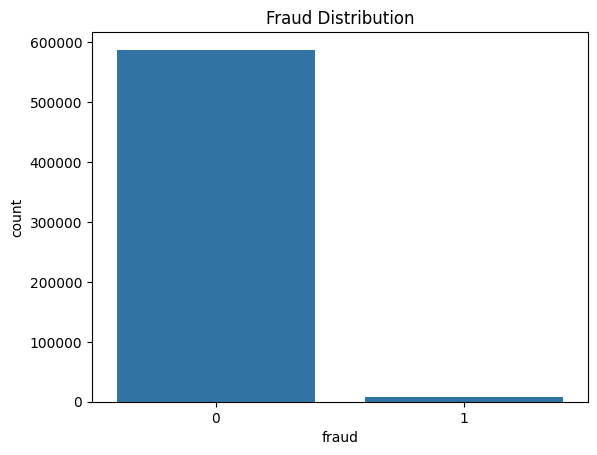

In [9]:
sns.countplot(x='fraud',data=df)
plt.title("Fraud Distribution")
plt.show()


### Insights

1. Data is highly imbalanced
2. Fraud cases are 1-2%
3. We need special handling in model training

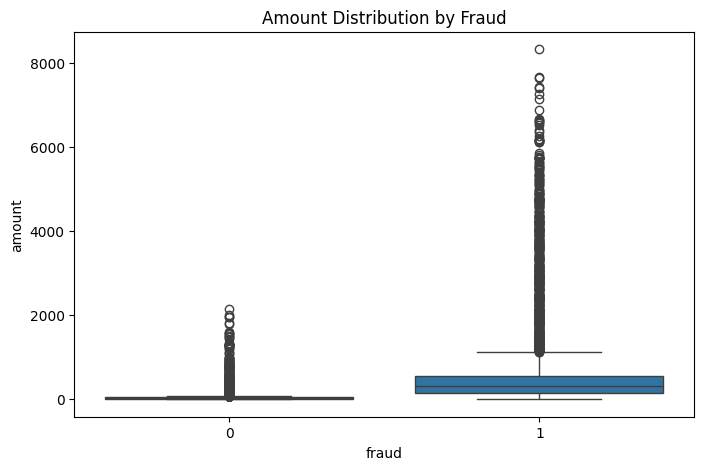

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='fraud',y='amount',data=df)
plt.title("Amount Distribution by Fraud")
plt.show()

In [11]:
df.groupby('fraud')['amount'].mean()

fraud
0     31.847230
1    530.926551
Name: amount, dtype: float64

### Insights

1. Higher amounts is strong identication of fraud cases
2. Fraud cases has higher mean

In [13]:
fraud_category = df.groupby('category')['fraud'].mean().sort_values(ascending=False)

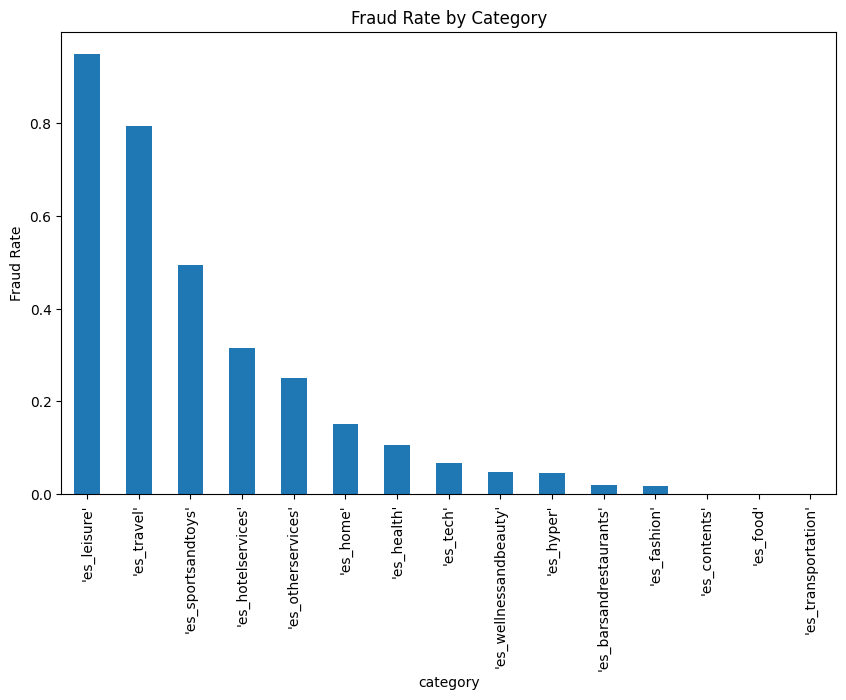

In [16]:
fraud_category.plot(kind ='bar',figsize=(10,6))
plt.title("Fraud Rate by Category")
plt.ylabel("Fraud Rate")
plt.show()

### Insights
1. Some categories show high fraud rate like es_leisure
2. Some show low fraud rate es_transportation
3. Categories show significant impact on fraud rate

In [17]:
df.groupby('merchant')['fraud'].mean().sort_values(ascending=False).head(10)

merchant
'M1294758098'    0.963351
'M3697346'       0.941558
'M1873032707'    0.864000
'M732195782'     0.851974
'M980657600'     0.832109
'M1353266412'    0.820513
'M857378720'     0.754098
'M2080407379'    0.750000
'M2011752106'    0.680328
'M17379832'      0.631206
Name: fraud, dtype: float64

### Insight:

1. Certain merchants have significantly high fraud rates.
2. Merchant feature may help model detect suspicious patterns.

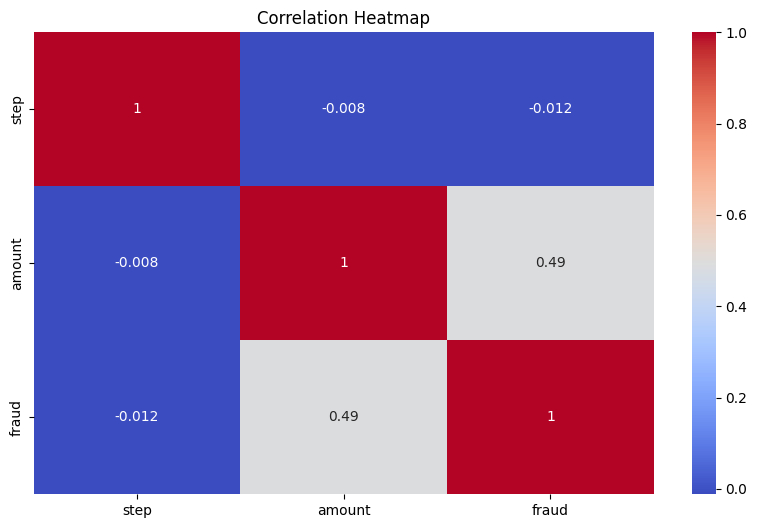

In [18]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Final EDA Conclusions

1. Dataset is highly imbalanced (~2% fraud).
2. Fraud transactions tend to have higher amounts.
3. Certain categories show significantly higher fraud rates.
4. Some merchants are strongly associated with fraud.
5. Age affects fraud probability.
6. Preprocessing must handle imbalance carefully.
7. Threshold tuning will be important during model deployment.

In [19]:
fraud_cases = df[df["fraud"] == 1]
fraud_cases.head(5)

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
88,0,'C583110837','3','M','28007','M480139044','28007','es_health',44.26,1
89,0,'C1332295774','3','M','28007','M480139044','28007','es_health',324.50,1
434,0,'C1160421902','3','M','28007','M857378720','28007','es_hotelservices',176.32,1
435,0,'C966214713','3','M','28007','M857378720','28007','es_hotelservices',337.41,1
553,0,'C1450140987','4','F','28007','M1198415165','28007','es_wellnessandbeauty',220.11,1
